# Project: Satellite Land Use Image Classifier (SVM + HOG)

# Satellite Images are into six class:
    Agricultural
    Airport
    Beach
    Forest
    Port
    Urban

# Using SVM Because
    works well on the High dimensional data and Effective also in the small dataset

In [15]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install hog

Note: you may need to restart the kernel to use updated packages.


In [17]:
import matplotlib.pyplot as plt

In [18]:
import os
import cv2
import numpy as np

In [19]:
from skimage.feature import hog  # for HOG Features Extraction

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix


#

# Dataset Folder Structure


In [21]:
Data_folders = [
    'agricultural',
    'airplane',
    'beach',
    'denseresidential',
    'forest',
    'harbor',
]

print(Data_folders)

['agricultural', 'airplane', 'beach', 'denseresidential', 'forest', 'harbor']


#

# Loading data and  Resizing of Images
    import os
    import cv2
    import numpy as np

In [22]:
# Step 1: Create empty lists
data = []
labels = []

# Step 2: Image size
img_size = 64

# Step 3: Loop through each class
for i in range(len(Data_folders)):
    
    category = Data_folders[i]
    folder_path = "Using_dataset/" + category
    
    # Step 4: Loop through each image in folder
    for file_name in os.listdir(folder_path):
        
        image_path = folder_path + "/" + file_name
        
        # Step 5: Read image
        image = cv2.imread(image_path)
        
        # Step 6: Check if image loaded properly
        if image is not None:
            
            # Step 7: Resize image
            image = cv2.resize(image, (img_size, img_size))
            
            # Step 8: Store data
            data.append(image)
            labels.append(i)

# Step 9: Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Step 10: Print results
print("Total images:", data.shape)
print("Total labels:", labels.shape)

Total images: (600, 64, 64, 3)
Total labels: (600,)


In [23]:
import os

print(os.listdir("Using_dataset"))
folder_path = "Using_dataset/" + category
folder_path = r"C:\Users\YourName\Desktop\Using_dataset\\" + category


['agricultural', 'airplane', 'beach', 'denseresidential', 'forest', 'harbor']


# Visualize 3 Samples per Class
    import matplotlib.pyplot as plt


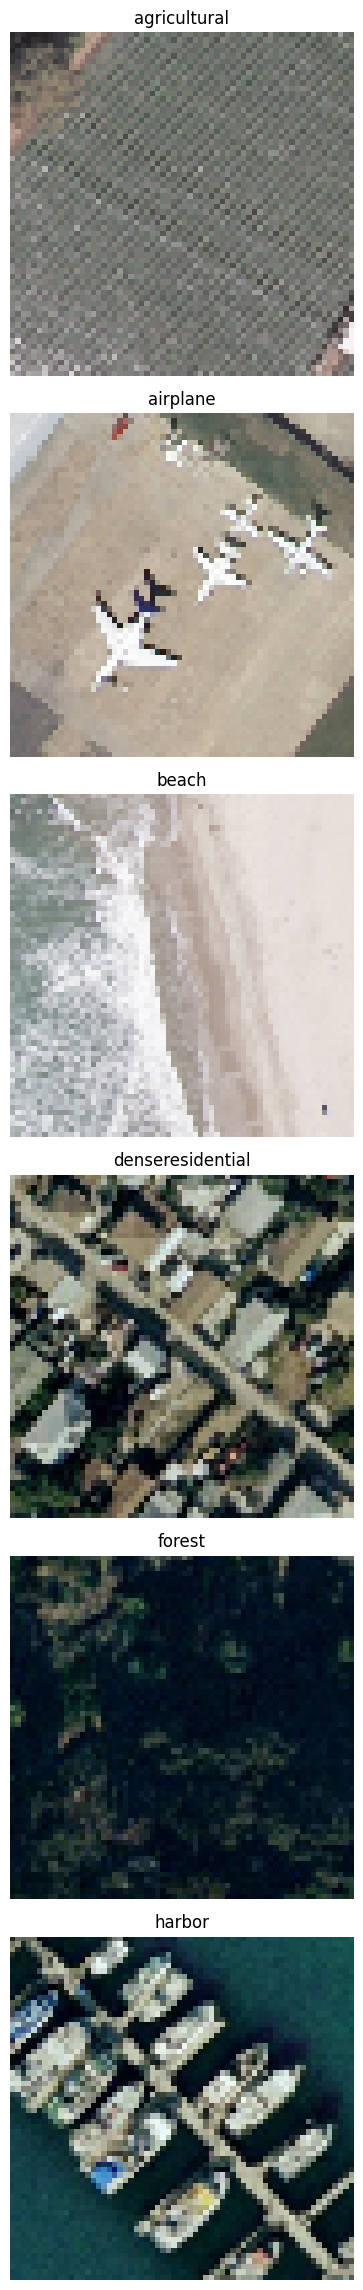

In [24]:
plt.figure(figsize=(40,23))

for i, category in enumerate(Data_folders):
    class_images = data[labels == i][:1]
    
    for j, img in enumerate(class_images):
        plt.subplot(6, 3, i*3 + j + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

# HOG Feature Extraction
    from skimage.feature import hog

In [25]:

hog_features = []

for img in data:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print("Image represented in Matrics:\n\n",gray)
    print()
    features = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8,8),
                   cells_per_block=(2,2),
                   block_norm='L2-Hys')
    
    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG shape:", hog_features.shape)

Image represented in Matrics:

 [[ 42  57  46 ... 162 110 100]
 [ 46  63  34 ... 124 100 115]
 [ 46  36  51 ...  96 147 122]
 ...
 [200 116 152 ... 113 109 126]
 [130 193 141 ... 114 126  92]
 [182 152 130 ... 128 107 130]]

Image represented in Matrics:

 [[115 147 145 ... 110 103 121]
 [117 123  98 ... 106 132  96]
 [119 110 140 ... 121 102 122]
 ...
 [123 123 112 ... 124 142 154]
 [132 113 131 ... 144 146 128]
 [100 138 116 ... 145 153  99]]

Image represented in Matrics:

 [[118 136 109 ... 107  99 117]
 [117 132 101 ... 117 136  84]
 [132  96  84 ... 136 100 130]
 ...
 [135 123  88 ... 125 113 107]
 [121  92 138 ... 123 104 126]
 [ 85 134 127 ...  97 128 112]]

Image represented in Matrics:

 [[110 127 118 ... 119 128 107]
 [129 108 125 ... 153 103 125]
 [108 118 120 ... 108 135 129]
 ...
 [140 113 139 ... 119 108 136]
 [ 98 154 120 ...  96 126 114]
 [148 118 114 ... 125 118 109]]

Image represented in Matrics:

 [[153 149 135 ... 135 119 119]
 [130 149 160 ... 121 114 122]
 [130 

#  Normalizing the  Features
    from sklearn.preprocessing import StandardScaler

In [26]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(hog_features)

print("These are the values of scaled:\n",X_scaled)

These are the values of scaled:
 [[-0.42918363  1.79274169  0.7658953  ...  0.7373555  -0.34371267
   1.3984177 ]
 [ 0.4242237   1.15735227  0.76506003 ... -1.25553835 -0.56586136
  -0.72220236]
 [ 0.55511389  1.77306704  1.60566361 ... -0.98568563 -0.36632781
  -0.51823334]
 ...
 [-0.22501835 -0.78551153  1.71575287 ... -1.21982072 -1.25173485
  -1.29450946]
 [-1.58823248 -1.27891409 -1.20540042 ... -1.21065846 -1.26555038
  -1.29450946]
 [ 0.4581498   1.04749932 -0.91501483 ... -1.22732667 -1.25205274
  -0.54778448]]


# Train-Test Split 
    from sklearn.model_selection import train_test_split


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, stratify=labels, random_state=42)

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

Linear Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        20
           1       0.87      0.65      0.74        20
           2       0.78      0.70      0.74        20
           3       0.88      0.70      0.78        20
           4       0.71      0.85      0.77        20
           5       0.68      0.75      0.71        20

    accuracy                           0.73       120
   macro avg       0.75      0.73      0.74       120
weighted avg       0.75      0.73      0.74       120



#

# : Linear SVM 
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score, classification_report

In [28]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

print("Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

Linear Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        20
           1       0.87      0.65      0.74        20
           2       0.78      0.70      0.74        20
           3       0.88      0.70      0.78        20
           4       0.71      0.85      0.77        20
           5       0.68      0.75      0.71        20

    accuracy                           0.73       120
   macro avg       0.75      0.73      0.74       120
weighted avg       0.75      0.73      0.74       120



# RBF Kernel SVM

In [29]:
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)
print()
y_pred_rbf = rbf_svm.predict(X_test)
print("Y prediction RBF values:\n",y_pred_rbf)
print()
print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))


Y prediction RBF values:
 [4 0 3 4 3 4 2 5 4 4 3 1 2 0 0 0 4 3 1 4 0 2 5 4 2 5 1 1 0 3 4 1 4 1 4 1 4
 5 3 2 3 0 2 1 5 0 0 0 5 3 2 1 2 5 5 5 4 4 2 0 3 2 4 5 3 0 4 2 3 3 3 2 2 5
 1 4 0 1 5 2 1 3 1 4 4 1 5 1 0 3 3 5 2 4 4 3 0 5 0 2 4 2 1 3 0 1 5 3 0 0 3
 3 5 1 1 1 5 5 4 1]

RBF Accuracy: 0.8833333333333333


#

# Hyperparameter Tuning
    from sklearn.model_selection import GridSearchCV

In [30]:


param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.001, 'scale'],
    'kernel': ['rbf']
}
print()
print("80% of training values->")
print()

print("X_training Values:\n",X_train)
print()
print("Y_training Values:\n",y_train)
print()
grid = GridSearchCV(SVC(), param_grid, cv=3, verbose=1)
grid.fit(X_train, y_train)
print()
print("Best Params:", grid.best_params_)


80% of training values->

X_training Values:
 [[ 0.34139623 -0.56456796  0.68457323 ... -0.06626828  0.08244603
   0.43667803]
 [-2.42136378 -1.09137472 -1.03241971 ... -1.18325176 -1.23875557
  -1.24156097]
 [ 0.27024047 -0.80414788 -0.67917987 ...  1.4950675   0.11851142
   0.83688119]
 ...
 [-1.33138542 -0.72875203  0.24166137 ... -0.36689061 -0.05274191
  -0.19095878]
 [ 1.1576814  -1.22948627  1.29978297 ... -0.97796099 -0.47555152
  -0.82401005]
 [ 1.49385425 -0.25615584  1.08789693 ...  1.39074453  0.04420357
  -0.83497046]]

Y_training Values:
 [0 5 0 2 0 2 2 2 0 1 5 2 1 1 3 0 4 3 5 3 2 5 3 2 5 1 0 5 5 1 0 4 5 3 2 1 5
 1 2 2 1 1 2 1 5 5 3 4 0 2 3 4 2 1 4 2 2 3 4 1 1 5 3 1 1 5 4 3 1 1 1 4 4 3
 4 3 4 1 0 4 3 3 2 4 0 4 3 0 4 4 0 2 5 0 2 4 2 5 1 3 5 2 0 4 1 4 5 4 0 2 2
 2 5 0 1 0 0 4 5 2 3 4 5 4 3 5 1 1 5 2 1 3 5 2 5 3 4 2 3 5 0 1 4 5 2 4 0 0
 1 1 0 1 3 1 0 3 3 0 3 3 0 1 0 5 5 0 0 2 4 1 2 0 4 3 2 5 2 3 4 3 4 5 0 3 0
 2 0 4 0 5 3 1 0 2 4 4 4 3 0 2 0 0 3 4 5 0 0 1 4 2 3 4 1 1 3 2 4 

# Final Evaluation
    from sklearn.metrics import confusion_matrix


In [31]:

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Y_Prediction values:\n",y_pred)
print()
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Confusion Matrix :\n",confusion_matrix(y_test, y_pred))
print()
print("Classification report:\n",classification_report(y_test, y_pred))

Y_Prediction values:
 [0 0 3 4 3 4 2 5 4 4 3 1 2 0 0 0 4 3 1 4 0 2 5 4 2 5 1 1 0 3 0 1 0 1 4 1 4
 5 3 2 3 0 2 1 5 0 0 0 5 3 2 1 2 5 5 5 4 4 2 0 3 2 4 5 3 0 4 2 3 3 3 2 2 5
 1 4 0 1 5 2 1 3 1 4 4 1 5 1 0 3 3 5 2 4 4 3 0 5 0 2 4 2 1 3 0 1 5 3 0 0 3
 1 5 1 1 1 5 5 4 1]

Final Accuracy: 0.8666666666666667

Confusion Matrix :
 [[18  0  0  1  1  0]
 [ 0 18  0  1  0  1]
 [ 2  0 16  0  1  1]
 [ 0  0  1 18  0  1]
 [ 2  0  0  0 18  0]
 [ 0  4  0  0  0 16]]

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        20
           1       0.82      0.90      0.86        20
           2       0.94      0.80      0.86        20
           3       0.90      0.90      0.90        20
           4       0.90      0.90      0.90        20
           5       0.84      0.80      0.82        20

    accuracy                           0.87       120
   macro avg       0.87      0.87      0.87       120
weighted avg       0.87      0.87   

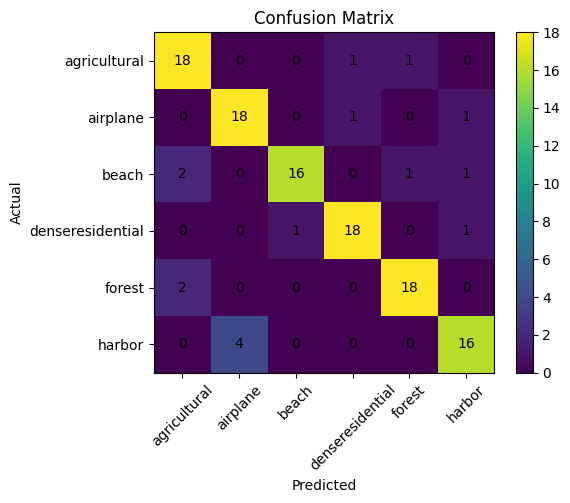

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Axis labels
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

# Class names on axis
plt.xticks(range(len(Data_folders)), Data_folders, rotation=45)
plt.yticks(range(len(Data_folders)), Data_folders)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=Data_folders
)

print("Classification Report:\n")
print(report)

Classification Report:

                  precision    recall  f1-score   support

    agricultural       0.82      0.90      0.86        20
        airplane       0.82      0.90      0.86        20
           beach       0.94      0.80      0.86        20
denseresidential       0.90      0.90      0.90        20
          forest       0.90      0.90      0.90        20
          harbor       0.84      0.80      0.82        20

        accuracy                           0.87       120
       macro avg       0.87      0.87      0.87       120
    weighted avg       0.87      0.87      0.87       120



# 1. Sample Images Visualization (Dataset Overview)

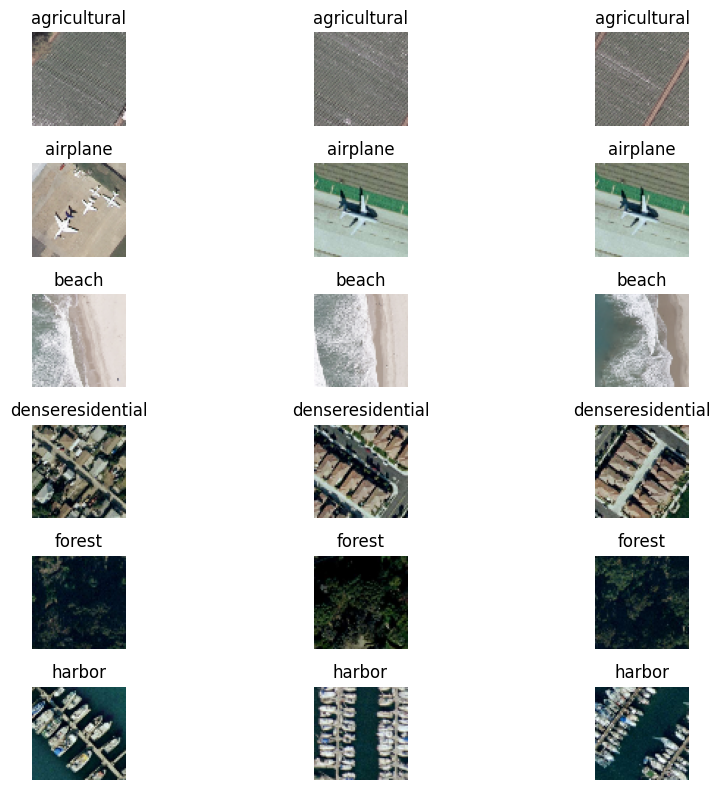

In [36]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10,8))

for i, category in enumerate(Data_folders):
    class_images = data[labels == i][:3]
    
    for j, img in enumerate(class_images):
        plt.subplot(6, 3, i*3 + j + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

# HOG Feature Visualization

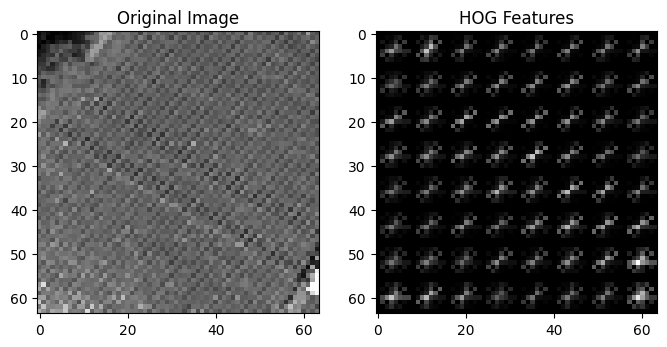

In [37]:
from skimage.feature import hog

img = data[0]
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

features, hog_image = hog(gray,
                          orientations=9,
                          pixels_per_cell=(8,8),
                          cells_per_block=(2,2),
                          visualize=True)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")

plt.show()

# Define Linear SVM Accuracy

In [50]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train Linear SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

# Predict
y_pred_linear = linear_svm.predict(X_test)

# Calculate accuracy
linear_acc = accuracy_score(y_test, y_pred_linear)

print("Linear Accuracy:", linear_acc)

Linear Accuracy: 0.7333333333333333


# Define RBF SVM Accuracy

In [51]:
# Train RBF SVM
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)

# Predict
y_pred_rbf = rbf_svm.predict(X_test)

# Calculate accuracy
rbf_acc = accuracy_score(y_test, y_pred_rbf)

print("RBF Accuracy:", rbf_acc)

RBF Accuracy: 0.8833333333333333


# Accuracy Comparison Graph (Linear vs RBF)

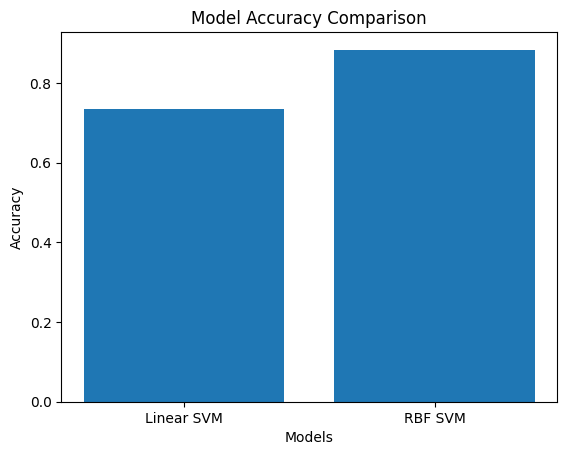

In [54]:
import matplotlib.pyplot as plt

models = ['Linear SVM', 'RBF SVM']
accuracies = [linear_acc, rbf_acc]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

# Class-wise F1 Score Bar Graph

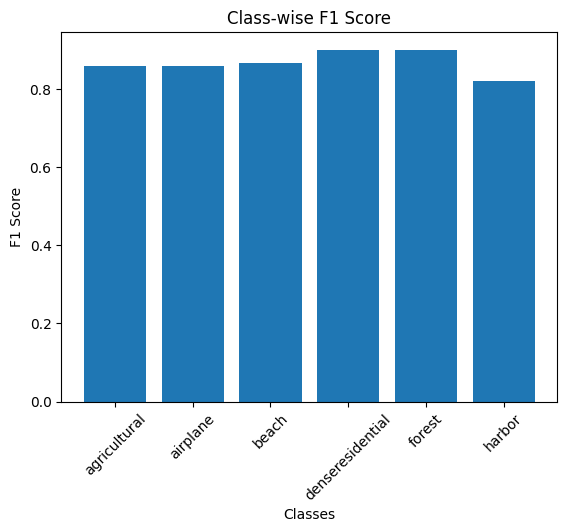

In [67]:
report = classification_report(
    y_test,
    y_pred,
    target_names=Data_folders,
    output_dict=True
)

f1_scores = []

for cls in Data_folders:
    f1_scores.append(report[cls]['f1-score'])

plt.figure()
plt.bar(Data_folders, f1_scores)

plt.xticks(rotation=45)
plt.title("Class-wise F1 Score")
plt.xlabel("Classes")
plt.ylabel("F1 Score")

plt.show()

# Box Plot (Feature Distribution)

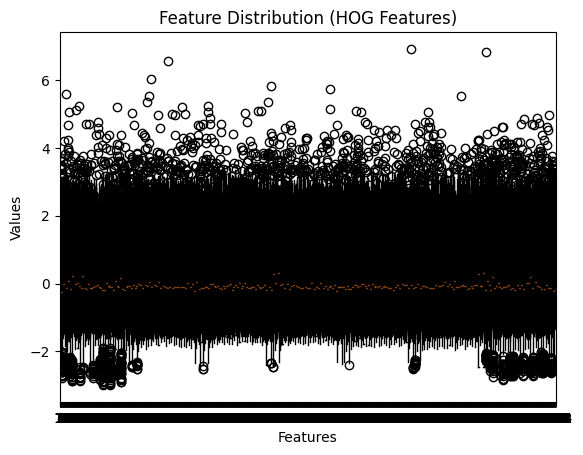

In [61]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(X_scaled)

plt.title("Feature Distribution (HOG Features)")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

#  Box Plot (Accuracy Distribution – Advanced)

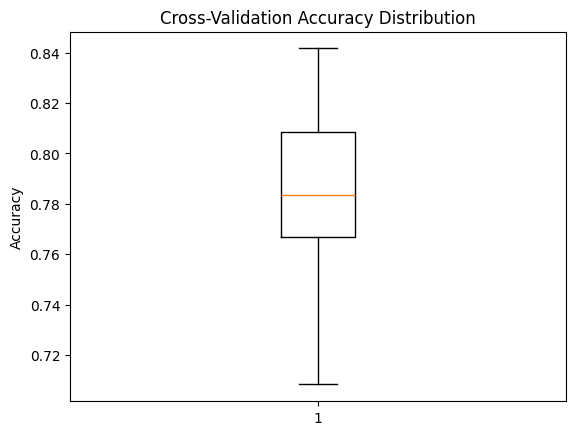

In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(SVC(kernel='rbf'), X_scaled, labels, cv=5)

plt.figure()
plt.boxplot(scores)

plt.title("Cross-Validation Accuracy Distribution")
plt.ylabel("Accuracy")

plt.show()

# Prediction Visualization (Actual vs Predicted)

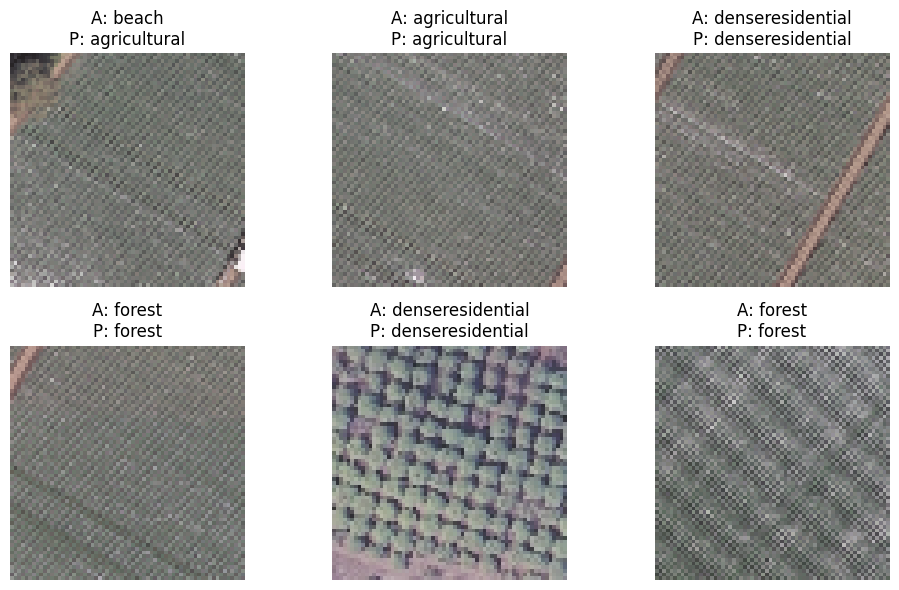

In [45]:
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = data[i]
    actual = Data_folders[y_test[i]]
    predicted = Data_folders[y_pred[i]]
    
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"A: {actual}\nP: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Box Plot (Accuracy Distribution – Advanced)

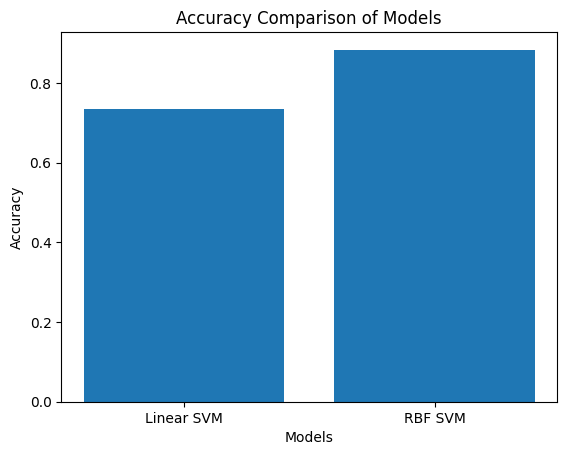

In [63]:
import matplotlib.pyplot as plt

# Example accuracies (use your actual values)
models = ['Linear SVM', 'RBF SVM']
accuracies = [linear_acc, rbf_acc]

plt.figure()
plt.bar(models, accuracies)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()